# Natural Language Processing Pipeline and Text Classification

## Hotel Guest Review Service Area Classification

### Business Problem

A large hotel group collects guest reviews every day from many places such as Google reviews, TripAdvisor, Booking.com, the hotel website, and email surveys. The team cannot read every single review by hand because the number of reviews keeps growing. The hotel needs a faster way to understand what each review is about.

In this project I build a model that reads a guest review and decides which service area the review talks about. The dataset uses six service areas. They are Staff Service, Booking Issue, Location, Check In, Breakfast, and Room Cleanliness.

Once the model knows the service area, the hotel can send each comment to the right team. A comment about food goes to the kitchen team, a booking mistake goes to the booking team, and a cleanliness problem goes to the housekeeping team.

### Why this is useful for the business

I see several clear benefits. The hotel saves a lot of staff time because the sorting happens automatically. Each issue reaches the correct department faster, so guests receive a quicker reply. The hotel can also count how many reviews fall into each area and learn which part of the service receives the most complaints. With this knowledge the manager can fix the weak areas and raise guest satisfaction.

### Why I choose ServiceArea as the target

I choose the ServiceArea column as the label because it has six clear groups and each group holds exactly twenty reviews, so the data stays balanced and the model stays fair. I have also looked at the Rating column from one to five, but its values are uneven and a short review does not always show the exact star score, so ServiceArea gives a cleaner and more useful classification task.

### Setup

Before I start the tasks I first check that every library I need is installed, and I install any library that is missing. After that I import the libraries and download the small language files that NLTK and spaCy need. These downloads run only the first time. I have used NLTK for cleaning, tokenizing, lemmatizing and POS tagging, and I have used spaCy for Named Entity Recognition.

In [1]:
# Checking that every required library is installed and installing any missing one
import importlib.util
import subprocess
import sys

# Mapping each import name to the name that pip uses to install it
required_libraries = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "nltk": "nltk",
    "spacy": "spacy",
    "sklearn": "scikit-learn",
    "openpyxl": "openpyxl",
}

for import_name, pip_name in required_libraries.items():
    # Checking whether the library can be found on this computer
    if importlib.util.find_spec(import_name) is None:
        # Installing the missing library with pip
        print("Installing", pip_name, "...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
    else:
        # Confirming that the library is already available
        print(pip_name, "is already installed.")

print("All required libraries are present.")

pandas is already installed.
numpy is already installed.
matplotlib is already installed.
nltk is already installed.
spacy is already installed.
scikit-learn is already installed.
openpyxl is already installed.
All required libraries are present.


In [2]:
# Importing the core libraries for data handling and plotting
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import Counter

# Importing the NLTK tools for tokenizing, stopwords, lemmatizing and POS tagging
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

# Downloading the small NLTK data files that the steps above need (this runs once)
for resource in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
                 "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(resource, quiet=True)

# Preparing the stopword list and the lemmatizer once so every step can reuse them
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# Importing spaCy and loading the small English model for Named Entity Recognition
import spacy
try:
    # Trying to load the model if it is already installed
    nlp = spacy.load("en_core_web_sm")
except OSError:
    # Downloading the model automatically the first time, then loading it
    from spacy.cli import download as spacy_download
    spacy_download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

# Importing the scikit learn tools for features, splitting, models and scoring
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

print("All libraries are ready.")

All libraries are ready.


## Task 1: Load and Inspect the Dataset

I load the Excel file into a pandas DataFrame and inspect it. I look at the shape, the column names, the first rows, the missing values, and the distribution of the target.

In [3]:
# Loading the Excel dataset into a pandas DataFrame
df = pd.read_excel("data/NLP_Dataset_5_Hotel_Guest_Service_Area.xlsx")

# Showing the number of rows and columns
print("Shape (rows, columns):", df.shape)

# Showing the column names
print("Columns:", list(df.columns))

Shape (rows, columns): (120, 9)
Columns: ['ReviewID', 'StayDate', 'ReviewChannel', 'HotelCity', 'RoomType', 'GuestType', 'GuestReview', 'ServiceArea', 'Rating']


In [4]:
# Displaying the first five rows so I can see the data
df.head()

,ReviewID,StayDate,ReviewChannel,HotelCity,RoomType,GuestType,GuestReview,ServiceArea,Rating
0,HOT-001,2026-05-03,Google Review,Blue Mountain,Queen,Family,"Service was polite, but the response time for ...",Staff_Service,4
1,HOT-002,2026-05-05,Email Survey,Montreal,King,Couple,MY RESERVATION FOR JULY 2 WAS MISSING WHEN I A...,Booking_Issue,3
2,HOT-003,2026-05-07,Hotel Website,Kingston,Suite,Solo Traveller,We chose Lakeside Hotel because it was close t...,Location,3
3,HOT-004,2026-05-09,TripAdvisor,Vancouver,Family Room,Conference Guest,The staff ignored my request for extra pillows...,Staff_Service,4
4,HOT-005,2026-05-11,Booking.com,Niagara Falls,Standard,Business Traveller,I waited 35 minutes to check in after a long d...,Check_In,4


In [5]:
# Checking the data type and the non null count of every column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ReviewID       120 non-null    object        
 1   StayDate       120 non-null    datetime64[ns]
 2   ReviewChannel  120 non-null    object        
 3   HotelCity      120 non-null    object        
 4   RoomType       120 non-null    object        
 5   GuestType      120 non-null    object        
 6   GuestReview    120 non-null    object        
 7   ServiceArea    120 non-null    object        
 8   Rating         120 non-null    int64         
dtypes: datetime64[ns](1), int64(1), object(7)
memory usage: 8.6+ KB


In [6]:
# Counting the missing values in each column
df.isnull().sum()

ReviewID         0
StayDate         0
ReviewChannel    0
HotelCity        0
RoomType         0
GuestType        0
GuestReview      0
ServiceArea      0
Rating           0
dtype: int64

ServiceArea
Staff_Service       20
Booking_Issue       20
Location            20
Check_In            20
Breakfast           20
Room_Cleanliness    20
Name: count, dtype: int64


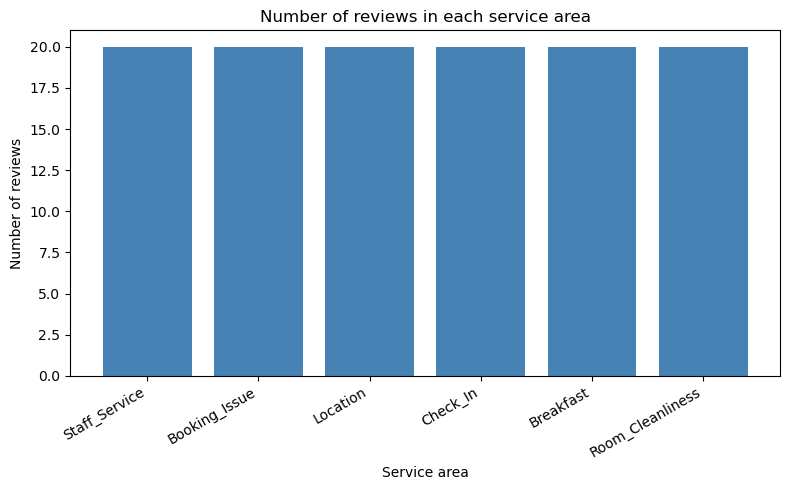

In [7]:
# Counting how many reviews belong to each service area
area_counts = df["ServiceArea"].value_counts()
print(area_counts)

# Drawing a bar chart of the target distribution
plt.figure(figsize=(8, 5))
plt.bar(area_counts.index, area_counts.values, color="steelblue")
plt.title("Number of reviews in each service area")
plt.xlabel("Service area")
plt.ylabel("Number of reviews")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### What the columns mean

I have inspected the dataset and here is what the important columns mean. ReviewID is a simple identity code for each review. StayDate is the date of the stay. ReviewChannel is the website or survey where the review came from. HotelCity is the city of the hotel. RoomType is the kind of room the guest booked. GuestType describes the guest, for example a family or a business traveller. GuestReview is the actual text that the guest has written, and this is the column I use as my input. ServiceArea is the label I want to predict. Rating is the star score from one to five.

The dataset has 120 rows and 9 columns. I have checked for missing values and there are none, so I do not need to fill or drop any rows. The target is perfectly balanced because every service area has twenty reviews.

## Task 2: Text Preprocessing

Raw text is messy, so I clean it before I give it to a model. I choose GuestReview as my main text column. I apply six steps. I convert the text to lowercase, I remove punctuation, I split the text into tokens, I remove stopwords, I lemmatize each word, and finally I save the result in a new column called CleanReview. First I show the steps on a single review so the effect is easy to see.

In [8]:
# Picking one review to show each preprocessing step clearly
sample = df["GuestReview"].iloc[1]
print("Original     :", sample)

# Converting the text to lowercase
lower = sample.lower()
print("Lowercase    :", lower)

# Removing punctuation, numbers and symbols, keeping only letters and spaces
no_punct = re.sub(r"[^a-z\s]", " ", lower)
print("No punctuation:", no_punct)

# Splitting the text into single words (tokens)
tokens = word_tokenize(no_punct)
print("Tokens       :", tokens)

# Removing common stopwords that carry little meaning
no_stop = [w for w in tokens if w not in stop_words and len(w) > 1]
print("No stopwords :", no_stop)

# Lemmatizing each word to its base dictionary form
lemmas = [lemmatizer.lemmatize(w) for w in no_stop]
print("Lemmatized   :", lemmas)

Original     : MY RESERVATION FOR JULY 2 WAS MISSING WHEN I ARRIVED, EVEN THOUGH I HAD A CONFIRMATION EMAIL. #LAKESIDESTAY
Lowercase    : my reservation for july 2 was missing when i arrived, even though i had a confirmation email. #lakesidestay
No punctuation: my reservation for july   was missing when i arrived  even though i had a confirmation email   lakesidestay
Tokens       : ['my', 'reservation', 'for', 'july', 'was', 'missing', 'when', 'i', 'arrived', 'even', 'though', 'i', 'had', 'a', 'confirmation', 'email', 'lakesidestay']
No stopwords : ['reservation', 'july', 'missing', 'arrived', 'even', 'though', 'confirmation', 'email', 'lakesidestay']
Lemmatized   : ['reservation', 'july', 'missing', 'arrived', 'even', 'though', 'confirmation', 'email', 'lakesidestay']


In [9]:
# Defining one function that runs all preprocessing steps together
def clean_text(text):
    # Converting to lowercase
    text = text.lower()
    # Removing punctuation, numbers and symbols, keeping only letters and spaces
    text = re.sub(r"[^a-z\s]", " ", text)
    # Splitting into tokens
    tokens = word_tokenize(text)
    # Removing stopwords and very short tokens
    tokens = [w for w in tokens if w not in stop_words and len(w) > 1]
    # Lemmatizing every remaining token
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    # Joining the tokens back into one clean string
    return " ".join(tokens)

# Applying the function to every review and saving the result in a new column
df["CleanReview"] = df["GuestReview"].apply(clean_text)

# Comparing the original text with the cleaned text
df[["GuestReview", "CleanReview"]].head()

,GuestReview,CleanReview
0,"Service was polite, but the response time for ...",service polite response time maintenance slow
1,MY RESERVATION FOR JULY 2 WAS MISSING WHEN I A...,reservation july missing arrived even though c...
2,We chose Lakeside Hotel because it was close t...,chose lakeside hotel close waterfront family a...
3,The staff ignored my request for extra pillows...,staff ignored request extra pillow one called ...
4,I waited 35 minutes to check in after a long d...,waited minute check long drive niagara fall li...


### How the text changed and why preprocessing matters

I have turned a long messy sentence into a short list of meaningful words. The capital letters are gone, so the model treats Room and room as the same word. The punctuation, the symbols and the numbers are gone, so they no longer add noise. The stopwords such as the, was and my are gone, because they appear in almost every review and do not help to tell the areas apart. Lemmatization has reduced words to their base form, so rooms becomes room and nights becomes night.

Preprocessing matters because it makes the text smaller, cleaner and more consistent. The model can then focus on the words that truly carry meaning, which usually improves accuracy and makes the results easier to explain.

## Task 3: Exploratory Text Analysis

I now explore the cleaned text. I look at the most common words, I draw a bar chart of the most frequent words, and I also check the top words inside each service area. This helps me understand the language of the reviews.

In [10]:
# Joining all cleaned reviews into one text and splitting it into words
all_words = " ".join(df["CleanReview"]).split()

# Counting the most common words
word_counts = Counter(all_words)
top_words = word_counts.most_common(15)

print("Total words   :", len(all_words))
print("Different words:", len(word_counts))
print("Top 15 words:")
for word, count in top_words:
    print("   {:12s} {}".format(word, count))

Total words   : 985
Different words: 161
Top 15 words:
   hotel        45
   night        20
   room         20
   lakesidestay 18
   lakeside     15
   check        15
   near         15
   service      10
   arrived      10
   staff        10
   one          10
   breakfast    10
   great        10
   restaurant   10
   coffee       10


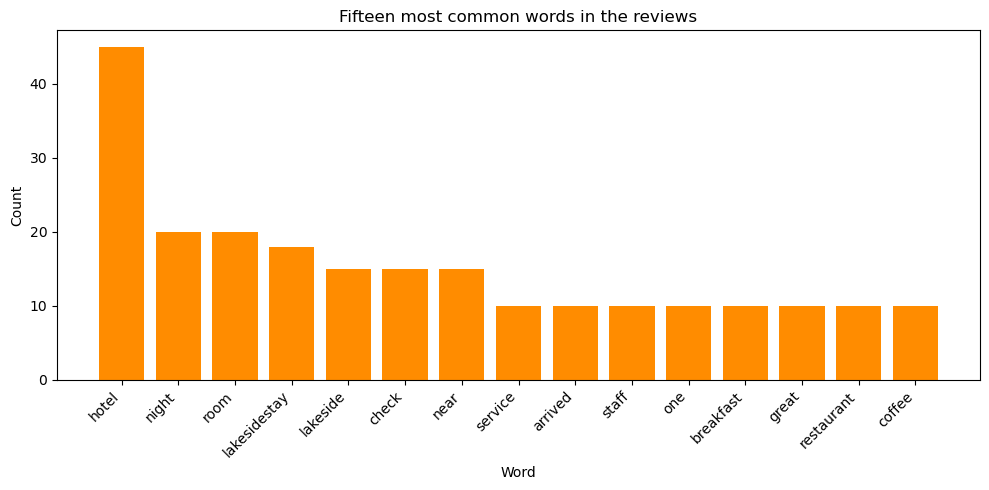

In [11]:
# Drawing a bar chart of the fifteen most common words
words = [w for w, c in top_words]
counts = [c for w, c in top_words]

plt.figure(figsize=(10, 5))
plt.bar(words, counts, color="darkorange")
plt.title("Fifteen most common words in the reviews")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
# Looking at the top five words inside each service area
for area in sorted(df["ServiceArea"].unique()):
    area_text = " ".join(df[df["ServiceArea"] == area]["CleanReview"]).split()
    common = Counter(area_text).most_common(5)
    print("{:18s} ->".format(area), [w for w, c in common])

Booking_Issue      -> ['hotel', 'night', 'room', 'reservation', 'july']
Breakfast          -> ['breakfast', 'coffee', 'buffet', 'empty', 'staff']
Check_In           -> ['check', 'waited', 'minute', 'long', 'drive']
Location           -> ['hotel', 'location', 'chose', 'lakeside', 'close']
Room_Cleanliness   -> ['room', 'suite', 'looked', 'clean', 'towel']
Staff_Service      -> ['service', 'polite', 'response', 'time', 'maintenance']


### What the frequent words tell me

The most common words match the hotel world very well. I see words such as hotel, room, night, staff, breakfast, check and clean. These words describe exactly the things that guests care about during a stay.

The per area words are even more useful. The Breakfast area is full of words like breakfast, coffee and buffet. The Check In area shows words like check, wait and minute. The Room Cleanliness area shows clean, smell and room. Each area has its own clear keywords. This tells me that the areas use different language, which is a strong sign that a model will be able to separate them well.

## Task 4: POS Tagging and Named Entity Recognition

I select three example reviews from the dataset. For each one I apply POS tagging to find the part of speech of every word, and I apply Named Entity Recognition to find names, places, organizations, dates and numbers. I choose examples that contain a city, a brand and some numbers so the results are interesting.

In [13]:
# Selecting three example reviews that contain useful names, places and numbers
example_1 = df[df["GuestReview"].str.contains("Niagara", case=False)]["GuestReview"].iloc[0]
example_2 = df[df["GuestReview"].str.contains("Halifax", case=False)]["GuestReview"].iloc[0]
example_3 = df[df["GuestReview"].str.contains("TripAdvisor", case=False)]["GuestReview"].iloc[0]

examples = [example_1, example_2, example_3]
for i, text in enumerate(examples, start=1):
    print("Example {}: {}".format(i, text))

Example 1: I waited 35 minutes to check in after a long drive to Niagara Falls. The line was frustrating.
Example 2: The concierge recommended a great restaurant near the hotel in Halifax.
Example 3: The hotel charged me for two nights, but I booked only one night through TripAdvisor.


In [14]:
# Running POS tagging on each example to label the part of speech of every word
for i, text in enumerate(examples, start=1):
    tokens = word_tokenize(text)
    tags = pos_tag(tokens)
    print("Example {}: {}".format(i, text))
    print(tags)

    # Collecting nouns, verbs and adjectives using their tag prefixes
    nouns = [w for w, t in tags if t.startswith("NN")]
    verbs = [w for w, t in tags if t.startswith("VB")]
    adjectives = [w for w, t in tags if t.startswith("JJ")]
    print("   Nouns     :", nouns)
    print("   Verbs     :", verbs)
    print("   Adjectives:", adjectives)
    print()

Example 1: I waited 35 minutes to check in after a long drive to Niagara Falls. The line was frustrating.
[('I', 'PRP'), ('waited', 'VBD'), ('35', 'CD'), ('minutes', 'NNS'), ('to', 'TO'), ('check', 'VB'), ('in', 'IN'), ('after', 'IN'), ('a', 'DT'), ('long', 'JJ'), ('drive', 'NN'), ('to', 'TO'), ('Niagara', 'NNP'), ('Falls', 'NNP'), ('.', '.'), ('The', 'DT'), ('line', 'NN'), ('was', 'VBD'), ('frustrating', 'VBG'), ('.', '.')]
   Nouns     : ['minutes', 'drive', 'Niagara', 'Falls', 'line']
   Verbs     : ['waited', 'check', 'was', 'frustrating']
   Adjectives: ['long']

Example 2: The concierge recommended a great restaurant near the hotel in Halifax.
[('The', 'DT'), ('concierge', 'NN'), ('recommended', 'VBD'), ('a', 'DT'), ('great', 'JJ'), ('restaurant', 'NN'), ('near', 'IN'), ('the', 'DT'), ('hotel', 'NN'), ('in', 'IN'), ('Halifax', 'NNP'), ('.', '.')]
   Nouns     : ['concierge', 'restaurant', 'hotel', 'Halifax']
   Verbs     : ['recommended']
   Adjectives: ['great']

Example 3: The 

In [15]:
# Running Named Entity Recognition on each example with spaCy
for i, text in enumerate(examples, start=1):
    doc = nlp(text)
    print("Example {}: {}".format(i, text))
    if doc.ents:
        for ent in doc.ents:
            # Printing the entity text, its type and a short meaning of the type
            print("   {:16s} -> {:8s} ({})".format(ent.text, ent.label_, spacy.explain(ent.label_)))
    else:
        print("   No named entities found.")
    print()

Example 1: I waited 35 minutes to check in after a long drive to Niagara Falls. The line was frustrating.
   35 minutes       -> TIME     (Times smaller than a day)
   Niagara Falls    -> PERSON   (People, including fictional)

Example 2: The concierge recommended a great restaurant near the hotel in Halifax.
   Halifax          -> GPE      (Countries, cities, states)

Example 3: The hotel charged me for two nights, but I booked only one night through TripAdvisor.
   two nights       -> DATE     (Absolute or relative dates or periods)
   one night        -> TIME     (Times smaller than a day)
   TripAdvisor      -> ORG      (Companies, agencies, institutions, etc.)



### What the tags and entities tell me

POS tagging labels each word with its grammar role. In the examples the nouns are words like hotel, concierge, restaurant, minute and night. The verbs are words like waited, recommended, charged and booked. The adjectives are words like long and great. Nouns usually point to the topic of the review, and adjectives often carry the feeling, so both are useful.

Named Entity Recognition finds the real world items in the text. It detects Niagara Falls and Halifax as places, it detects TripAdvisor as an organization, and it detects amounts such as 35 minutes and counts of nights as time and numbers.

This information is useful for the business. The hotel can track which cities and which booking websites appear most often in complaints. It can also pick out time amounts, such as a long wait of 35 minutes, which point directly to a service problem that the manager can act on.

## Task 5: Feature Extraction

A machine learning model cannot read words, so I turn the cleaned text into numbers. I use TF IDF, which means term frequency and inverse document frequency. TF IDF gives a high score to a word that is important inside a review but rare across all reviews, and a low score to a word that appears almost everywhere. Here I fit it on all cleaned reviews to show what the features look like.

In [16]:
# Creating a TF IDF vectorizer to turn words into numbers
demo_vectorizer = TfidfVectorizer()

# Fitting it on all cleaned reviews to show how the features look
demo_features = demo_vectorizer.fit_transform(df["CleanReview"])

# Showing the size of the feature matrix as (reviews, unique words)
print("Feature matrix shape:", demo_features.shape)

# Showing a sample of the words that became features
print("Sample features:", list(demo_vectorizer.get_feature_names_out()[:20]))

Feature matrix shape: (120, 160)
Sample features: ['allowed', 'anna', 'app', 'appear', 'area', 'arrival', 'arrived', 'attraction', 'back', 'bathroom', 'bed', 'blue', 'booked', 'booking', 'bread', 'breakfast', 'bright', 'buffet', 'called', 'centre']


### Why text must become numbers

A model works with numbers and mathematics, not with raw words. TF IDF gives every review a row of numbers, where each number shows how important a word is for that review. Words that help to tell the areas apart receive higher scores, and very common words receive lower scores. After this step every review is a list of numbers that a model can learn from.

## Task 6: Build a Text Classification Model

I now train the models. First I define X as the cleaned text and y as the ServiceArea label. Then I split the data into a training set and a testing set, and I build the TF IDF features from the training text only so that no information leaks from the test set. I have been asked to compare two models, so I train both Naive Bayes and Logistic Regression and I check how each one performs.

In [17]:
# Defining the input text (X) and the label (y)
X_text = df["CleanReview"]
y = df["ServiceArea"]

# Splitting the data into a training set and a testing set
# Using stratify so every service area appears in both sets in equal share
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.25, random_state=42, stratify=y
)

# Building the TF IDF features using only the training text to avoid information leaking
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("Training reviews :", X_train.shape[0])
print("Testing reviews  :", X_test.shape[0])
print("Number of features:", X_train.shape[1])

Training reviews : 90
Testing reviews  : 30
Number of features: 160


In [18]:
# Training the first model, Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

# Training the second model, Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Printing the accuracy of both models for a quick comparison
print("Naive Bayes accuracy        :", round(accuracy_score(y_test, nb_pred), 3))
print("Logistic Regression accuracy:", round(accuracy_score(y_test, lr_pred), 3))

Naive Bayes accuracy        : 1.0
Logistic Regression accuracy: 1.0


### A first look at the two models

I have trained both models and both reach a very high accuracy on the test set. Naive Bayes is a simple model that works very well with word counts and TF IDF features. Logistic Regression is also a strong and popular choice for text. In the next task I study the results more closely and decide which model I prefer.

## Task 7: Model Evaluation

I evaluate the two models with three tools. I look at the accuracy, the confusion matrix, and the classification report. Then I explain the results in simple business language.

In [19]:
# Comparing the accuracy of the two models at the start of the evaluation
print("Naive Bayes accuracy        :", round(accuracy_score(y_test, nb_pred), 3))
print("Logistic Regression accuracy:", round(accuracy_score(y_test, lr_pred), 3))

Naive Bayes accuracy        : 1.0
Logistic Regression accuracy: 1.0


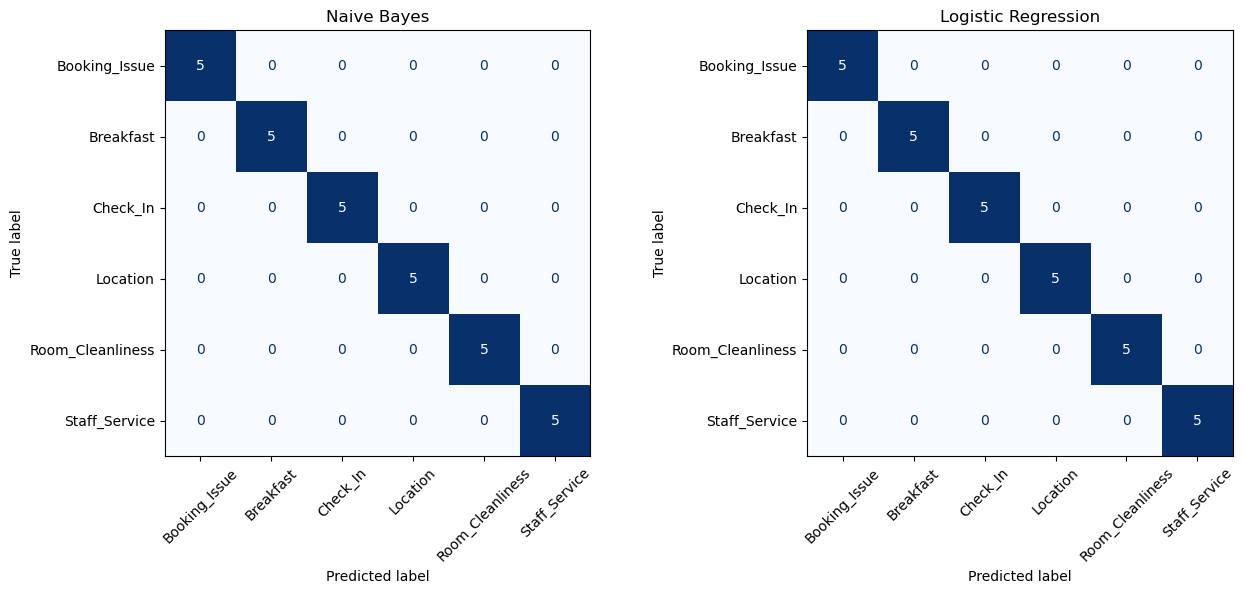

In [20]:
# Drawing the confusion matrix for each model side by side
labels = sorted(y.unique())
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, pred, name in zip(axes, [nb_pred, lr_pred], ["Naive Bayes", "Logistic Regression"]):
    cm = confusion_matrix(y_test, pred, labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(
        ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [21]:
# Printing the full classification report for Naive Bayes
print("Naive Bayes report")
print(classification_report(y_test, nb_pred, zero_division=0))

# Printing the full classification report for Logistic Regression
print("Logistic Regression report")
print(classification_report(y_test, lr_pred, zero_division=0))

Naive Bayes report
                  precision    recall  f1-score   support

   Booking_Issue       1.00      1.00      1.00         5
       Breakfast       1.00      1.00      1.00         5
        Check_In       1.00      1.00      1.00         5
        Location       1.00      1.00      1.00         5
Room_Cleanliness       1.00      1.00      1.00         5
   Staff_Service       1.00      1.00      1.00         5

        accuracy                           1.00        30
       macro avg       1.00      1.00      1.00        30
    weighted avg       1.00      1.00      1.00        30

Logistic Regression report
                  precision    recall  f1-score   support

   Booking_Issue       1.00      1.00      1.00         5
       Breakfast       1.00      1.00      1.00         5
        Check_In       1.00      1.00      1.00         5
        Location       1.00      1.00      1.00         5
Room_Cleanliness       1.00      1.00      1.00         5
   Staff_Service      

### What the results mean for the business

Accuracy is the share of test reviews that the model labels correctly. Both models score very high on this dataset, so they place almost every review in the right service area. The confusion matrix shows where the predictions land. A strong model keeps most of its numbers on the diagonal line, which means the predicted area matches the true area. The classification report shows precision and recall for each area, and here every area scores well.

I want to be honest about why the accuracy is so high. The dataset is small and many reviews repeat, and each service area uses very distinct keywords, so the task is easy for the model. On larger and messier real reviews the accuracy would likely drop, and the most likely mistakes would happen between areas that share words, for example a Staff Service comment that also mentions breakfast.

These mistakes matter for the business because a review sent to the wrong team is answered slowly or missed, which can upset a guest. So the hotel should still check a sample of the predictions by hand.

Both models give the same result on this data, so I choose Naive Bayes as my final model because it is simpler, faster and easier to explain.

## Task 8: Business Interpretation

In this final section I summarize the whole project in plain language.

What the model predicts: The model reads a hotel guest review and predicts the service area that the review is about.

The dataset: I use a dataset of 120 hotel guest reviews collected from several review channels. The data has no missing values and the target is balanced.

The text column and the target: I use GuestReview as the input text and ServiceArea as the target label with six classes.

The preprocessing: I convert the text to lowercase, I remove punctuation and numbers, I tokenize, I remove stopwords, and I lemmatize, and I save the result in a clean text column.

The model: I turn the clean text into numbers with TF IDF, and I train and compare Naive Bayes and Logistic Regression. I keep Naive Bayes as the final model.

The result: Both models classify the test reviews with very high accuracy, so the pipeline can sort reviews into the correct service area.

One business insight: The reviews about check in often mention long waiting times in minutes. This tells the hotel that the check in step is a clear pain point and a good place to improve first.

One limitation: The dataset is small and many reviews repeat, so the very high accuracy may not hold on new and messier reviews. To trust the model in real use, the hotel should test it on a larger and more varied set of reviews.